# **EXOPLANET HABITABILITY CLASSIFICATION PROJECT**

### RIDIMA

This notebook is a ML project, classifying exoplanets on their habitability from various mission data. 

In [1]:
#Import all the essentials libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import dabl as db



from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV,StratifiedKFold
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.utils import resample
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, classification_report, confusion_matrix 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from eli5.sklearn import PermutationImportance




#Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier as Ovr
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

In [47]:
#Open the data
df = pd.read_csv("phl_exoplanet_catalog_2019.csv")
df.head()

,P_NAME,P_STATUS,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_RADIUS,P_RADIUS_ERROR_MIN,P_RADIUS_ERROR_MAX,P_YEAR,P_UPDATED,...,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG,P_RADIUS_EST,P_MASS_EST,P_SEMI_MAJOR_AXIS_EST
0,11 Com b,3.0,6165.86330,-476.74200,476.74200,NaN,NaN,NaN,2007,2014-05-14,...,0,Hot,0,0.083813,Coma Berenices,Com,Berenice's Hair,12.082709,6165.86330,1.29
1,11 UMi b,3.0,4684.78480,-794.57001,794.57001,NaN,NaN,NaN,2009,2018-09-06,...,0,Hot,0,0.082414,Ursa Minor,UMi,Little Bear,12.229641,4684.78480,1.53
2,14 And b,3.0,1525.57440,NaN,NaN,NaN,NaN,NaN,2008,2014-05-14,...,0,Hot,0,0.081917,Andromeda,And,Andromeda,12.848516,1525.57440,0.83
3,14 Her b,3.0,1481.07850,-47.67420,47.67420,NaN,NaN,NaN,2002,2018-09-06,...,0,Cold,0,0.145241,Hercules,Her,Hercules,12.865261,1481.07850,2.93
4,16 Cyg B b,3.0,565.73385,-25.42624,25.42624,NaN,NaN,NaN,1996,2018-09-06,...,1,Warm,0,0.368627,Cygnus,Cyg,Swan,13.421749,565.73385,1.66


In [48]:
with open("column_names.txt", "w") as f:
    for i, col in enumerate(df.columns, start=1):
        f.write(f"{i}. {col}\n")
df.columns

Index(['P_NAME', 'P_STATUS', 'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX',
       'P_RADIUS', 'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX', 'P_YEAR',
       'P_UPDATED',
       ...
       'P_HABZONE_CON', 'P_TYPE_TEMP', 'P_HABITABLE', 'P_ESI',
       'S_CONSTELLATION', 'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG',
       'P_RADIUS_EST', 'P_MASS_EST', 'P_SEMI_MAJOR_AXIS_EST'],
      dtype='object', length=112)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4048 entries, 0 to 4047
Columns: 112 entries, P_NAME to P_SEMI_MAJOR_AXIS_EST
dtypes: float64(94), int64(4), object(14)
memory usage: 3.5+ MB


In [50]:
shape = df.shape
print(f'Rows: {shape[0]}')
print(f'Columns: {shape[1]}')

Rows: 4048
Columns: 112


Our target column is P_HABITABLE< which is a multiclass column.

Let's visualize the imbalance

# **EDA**

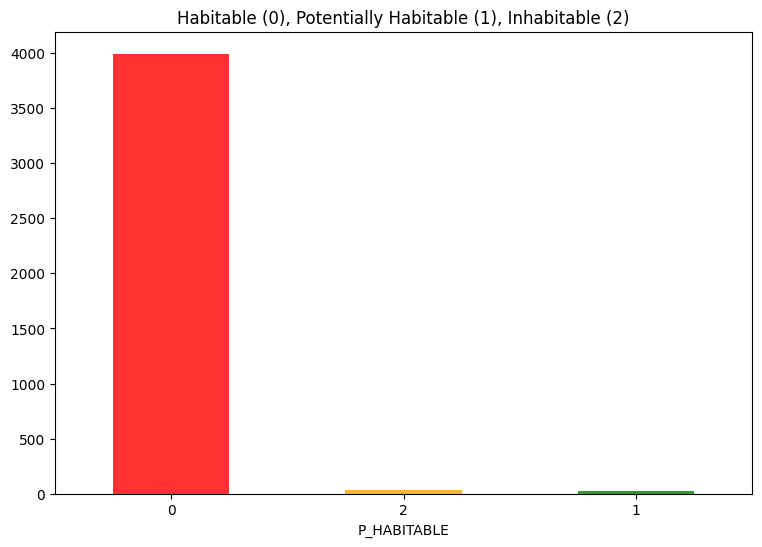

In [51]:
fig = plt.figure(figsize = (9,6))

df.P_HABITABLE.value_counts(ascending=False).plot(kind = 'bar', color= ['red', 'orange', 'green'], alpha = 0.8, rot = 0)

plt.title('Habitable (0), Potentially Habitable (1), Inhabitable (2)')
plt.savefig("Class-Imbalance.png")
plt.show()

Target looks like classification
Showing only top 10 of 84 continuous features
Linear Discriminant Analysis training set score: 0.865


[<Axes: title={'center': 'Target distribution'}, xlabel='count', ylabel='P_HABITABLE'>,
 [<Figure size 2000x600 with 10 Axes>,
  array([[<Axes: title={'center': '0.773'}, xlabel='P_ESI', ylabel='S_TIDAL_LOCK'>,
          <Axes: title={'center': '0.743'}, xlabel='P_ESI', ylabel='P_TEMP_EQUIL'>,
          <Axes: title={'center': '0.727'}, xlabel='P_ESI', ylabel='P_TPERI'>,
          <Axes: title={'center': '0.724'}, xlabel='P_ESI', ylabel='P_TEMP_EQUIL_MAX'>]],
        dtype=object),
  <Figure size 1600x400 with 4 Axes>,
  <Figure size 400x400 with 1 Axes>],
 array([[<Axes: title={'center': 'P_TYPE_TEMP'}>,
         <Axes: title={'center': 'P_TYPE'}>,
         <Axes: title={'center': 'S_TYPE_TEMP'}>,
         <Axes: title={'center': 'P_DETECTION'}>]], dtype=object)]

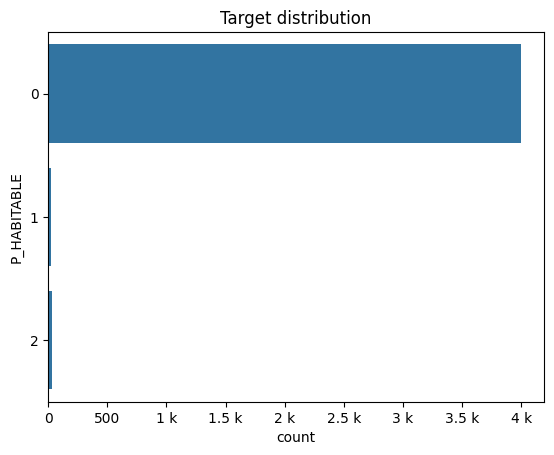

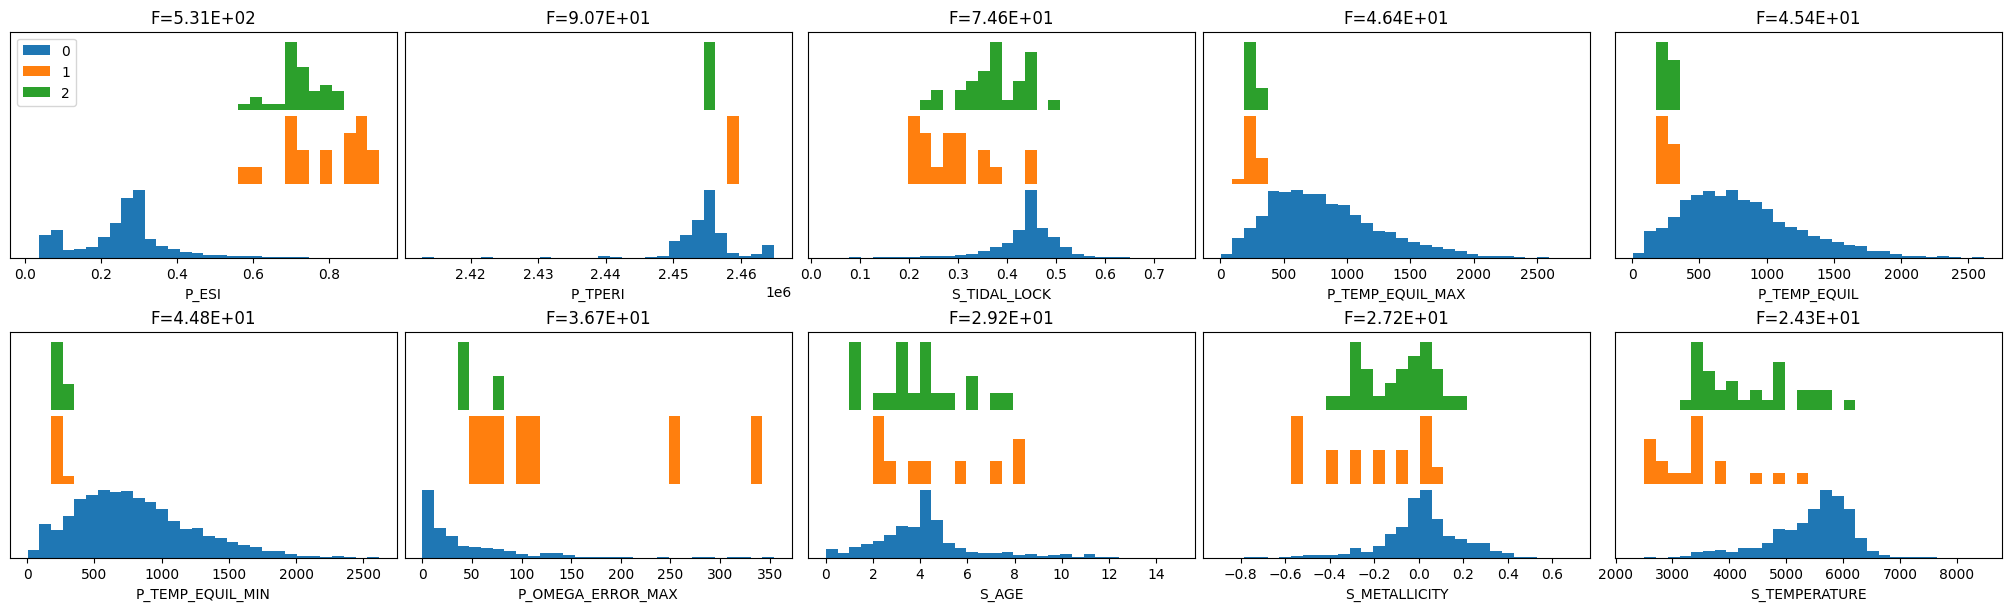

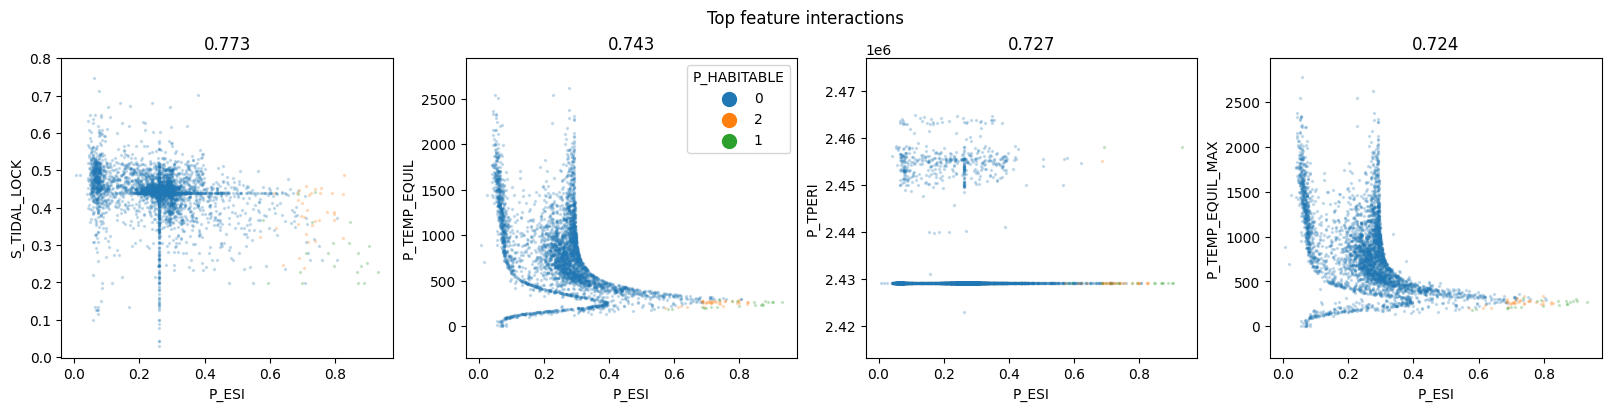

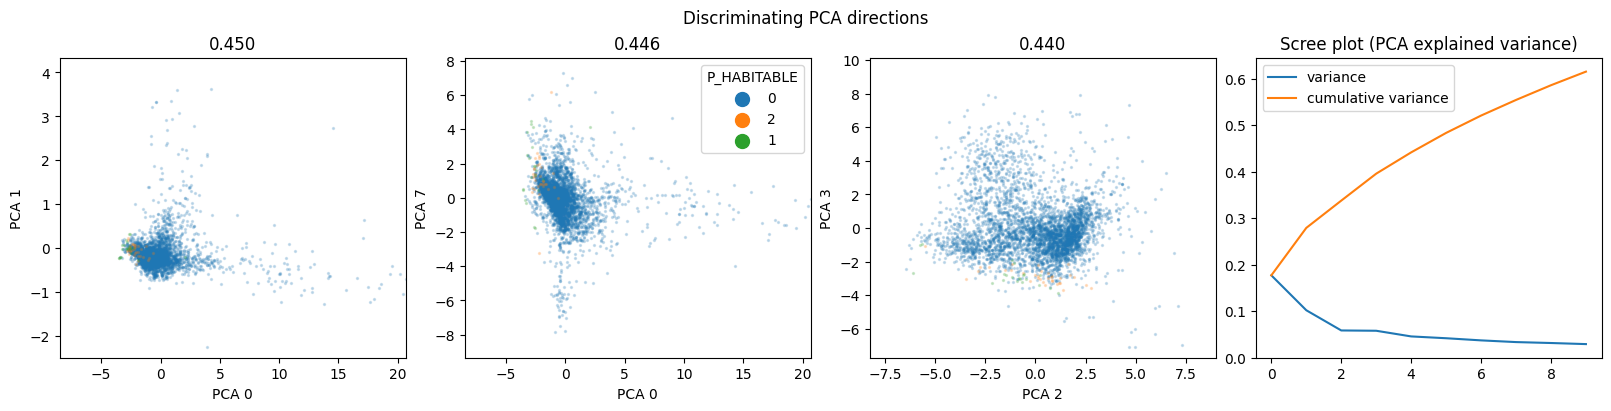

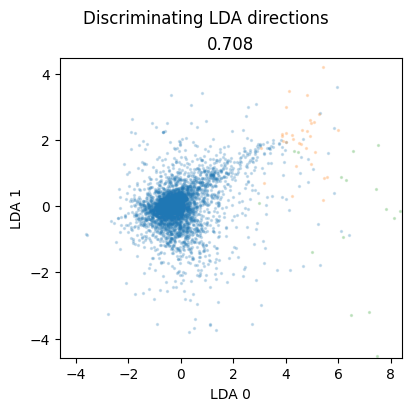

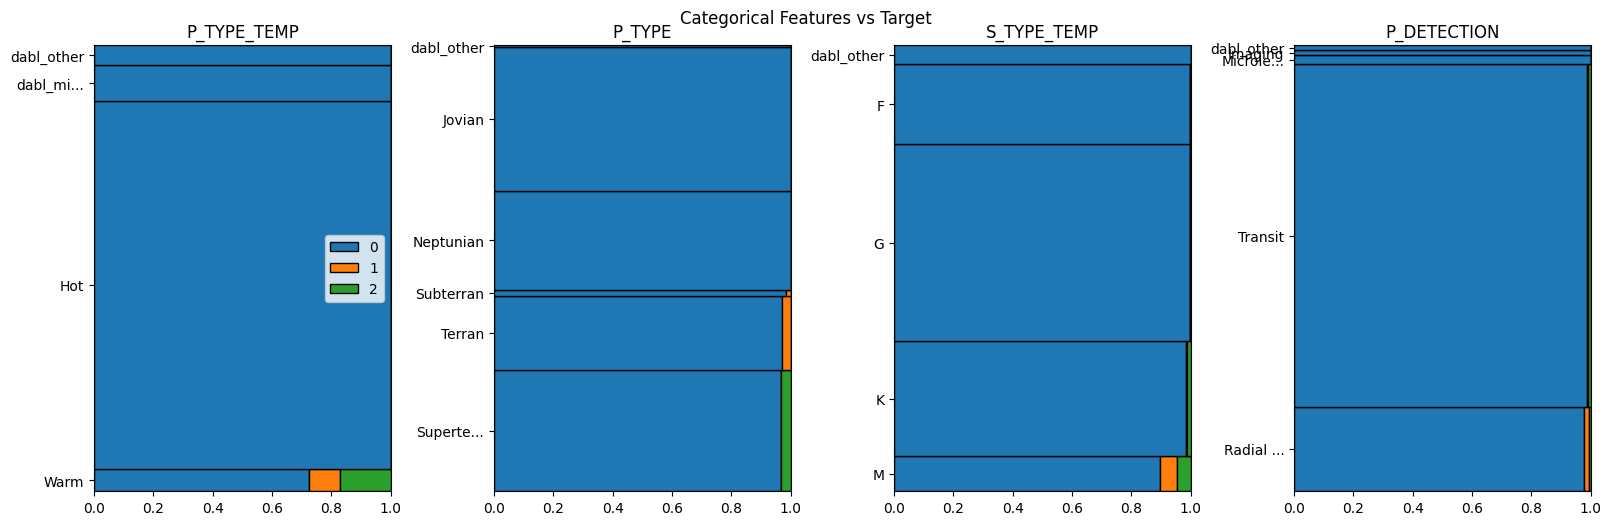

In [52]:
import warnings
warnings.filterwarnings('ignore')
db.plot(df, target_col='P_HABITABLE')

In [53]:
count = df['P_HABITABLE'].value_counts().sort_index()
total = count.sum()
percentage  = (count/total)*100
print(f'Percentage of class Imbalance:  ${percentage}')

Percentage of class Imbalance:  $P_HABITABLE
0    98.641304
1     0.518775
2     0.839921
Name: count, dtype: float64


Clearly the dataset is imabalnce as it have 98% inhabitable planets, 0.83% potentially habitable and 0.51% habitable planets.

We can resolve the class Imbalance with simple oversampling strateg


In [42]:
inhabitable = df[df.P_HABITABLE == 0]
potential_habitable = df[df.P_HABITABLE == 1]
habitable = df[df.P_HABITABLE == 2]

potential_habitable_df = resample(potential_habitable, replace = True, n_samples=len(inhabitable), random_state=42)

df = pd.concat([inhabitable, potential_habitable_df])

habitable_df = resample(habitable, replace=True, n_samples=len(inhabitable), random_state=42)

df = pd.concat([df,habitable_df])

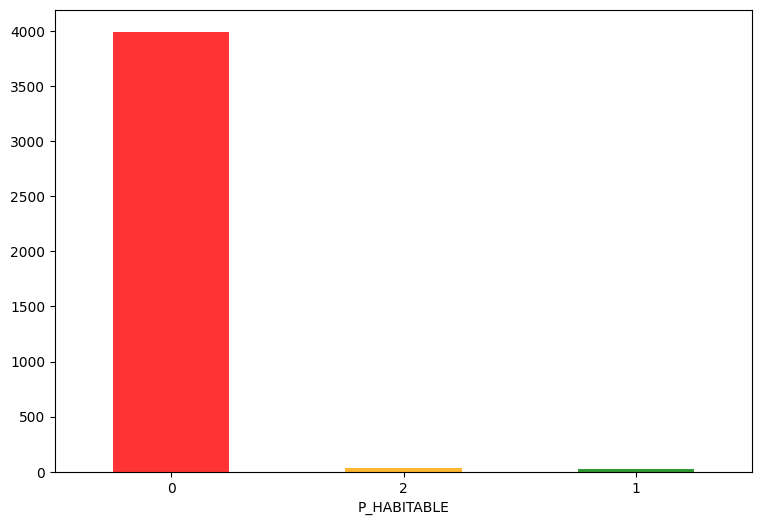

In [11]:
#plotting the new balanced target column
fig = plt.figure(figsize = (9,6))
df.P_HABITABLE.value_counts(ascending = False).plot(kind = 'bar', color=['red', 'orange', 'green'], alpha = 0.8 , rot =0 )

plt.savefig("Resampled-plot.png")
plt.show()

# **Data Analysis Through Visualization**

We can visualize, what techniques were used to detect exoplanets

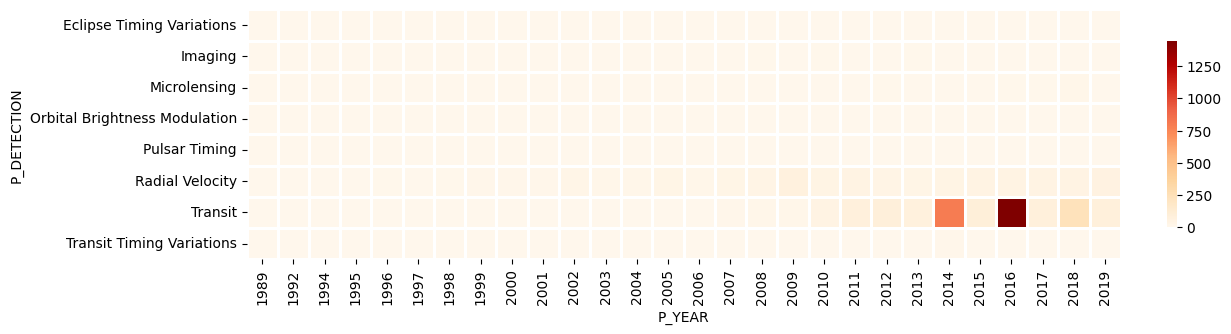

In [12]:
planet_detect = (df.groupby("P_DETECTION").filter(lambda x: len(x)>5)).groupby(['P_DETECTION', 'P_YEAR']).size().unstack(fill_value=0)

plt.figure(figsize=(12,12))
g = sns.heatmap(
    planet_detect, 
    square=True, 
    cbar_kws={'fraction' : 0.01}, 
    cmap='OrRd',
    linewidth=1
)
plt.savefig('Detection-method-by-year.png')

We can observe that Transit and Radial Velocity detection technique had been used extensively for discovering exoplanets

Now we can plot habitability of these planets detected by the two detection methods

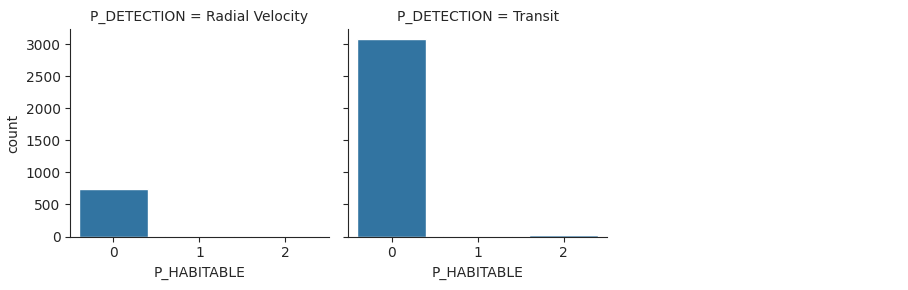

In [13]:
with sns.axes_style(style='ticks'):
    g = sns.catplot(x = "P_HABITABLE", 
                    col="P_DETECTION", 
                    col_wrap=3, 
                    data=df[
                        df['P_DETECTION'].isin(['Radial Velocity','Transit'])],
                    kind="count",
                    height=3.0, 
                    aspect=1.0)

plt.savefig("Class-Distro-by-method-detection.png")

Radial Velocity technique detected potentially habitual exoplanets and Transit method discovered more habitual and inhabitable planets more

Now we can analyze which planet (under which star) was discovered in which year.

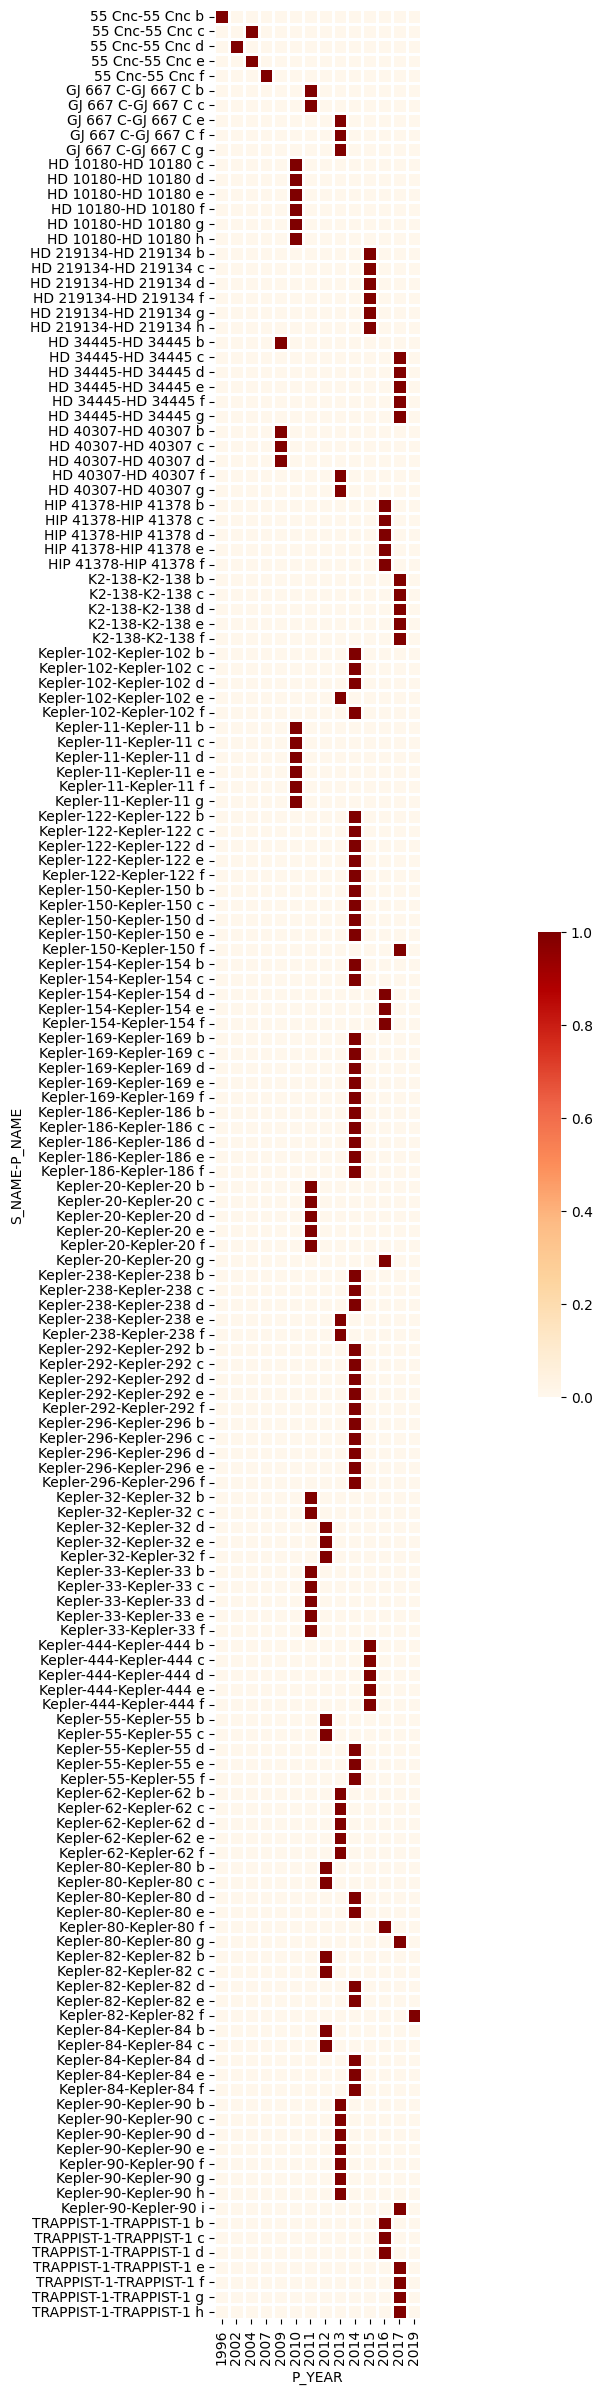

In [17]:
planet_under_star = (df.groupby("S_NAME").filter(lambda x: len(x)>4).groupby(['S_NAME', 'P_NAME', 'P_YEAR']).size().unstack(fill_value = 0))

plt.figure(figsize=(30,30))

g = sns.heatmap(planet_under_star,square=True, cbar_kws={'fraction':0.01},cmap='OrRd', linewidths=1)

We can observe that for star series GJ667, planets were discovered in 2008-2009, for Kepler series star, planets were discovered in somewhere 2011-2014 and for Trapist and Teegarden series star they were discovered in between 2017-2019.


-----------------------------------------------------------------------------

Now we can explore how planet type, star spectral type and planet thermal type influences habitability of exoplanet.

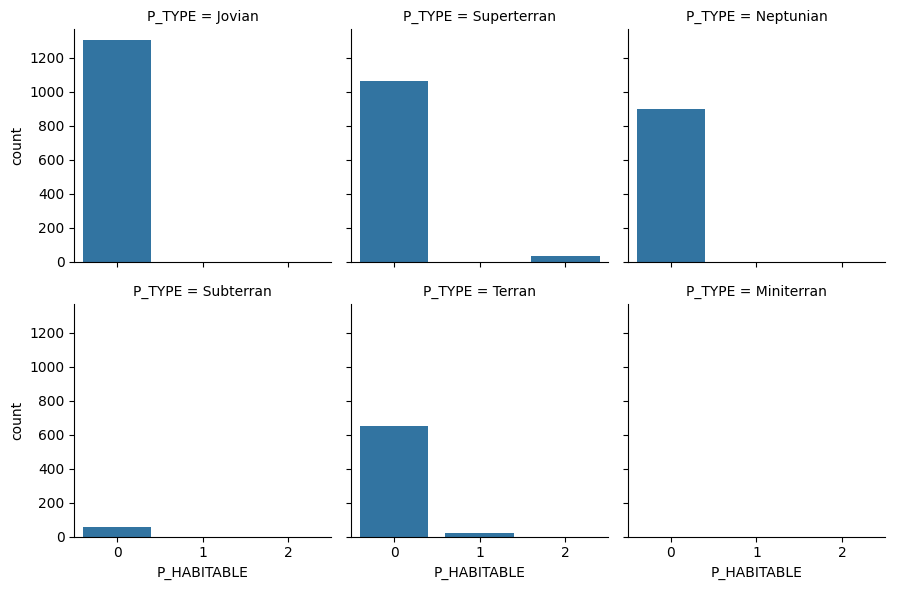

In [18]:
sns.axes_style(style='ticks')
g = sns.catplot(x = "P_HABITABLE", col = "P_TYPE", col_wrap=3, data = df, kind = 'count', height= 3,aspect=1.0)
plt.savefig("P_type-by-class-distro.png")

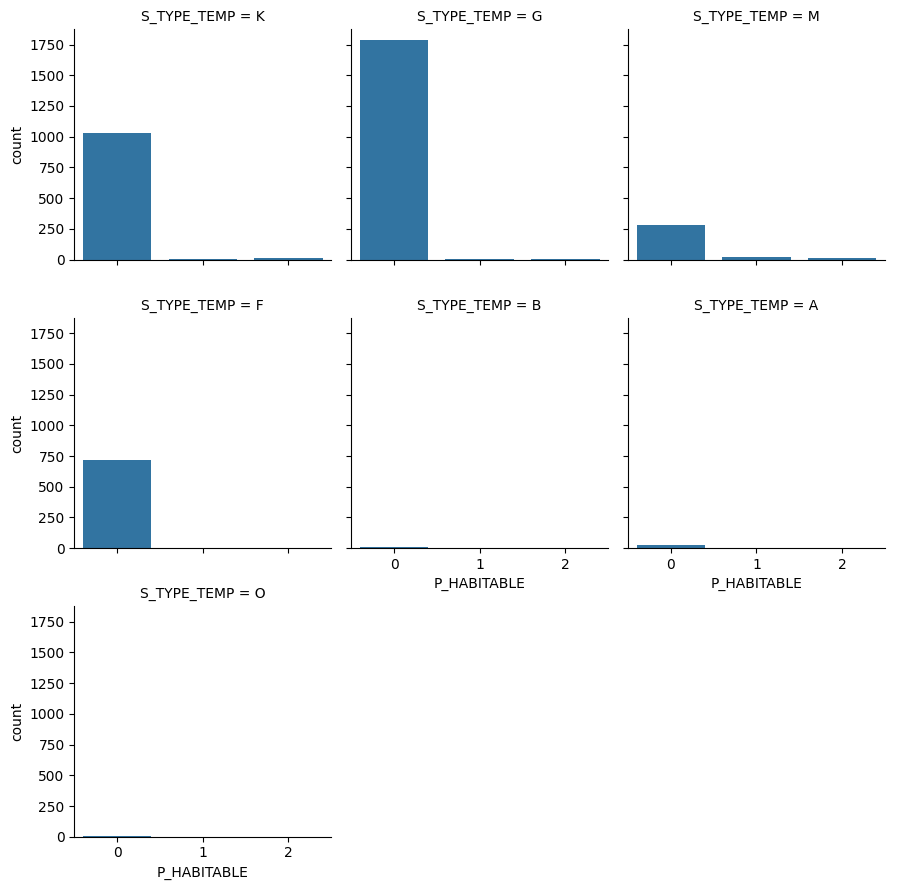

In [15]:
sns.axes_style(style='ticks')
g = sns.catplot(x = "P_HABITABLE", col = "S_TYPE_TEMP", col_wrap=3, data = df, kind = 'count', height= 3,aspect=1.0)
plt.savefig("S_type_temp-by-class-distro.png")

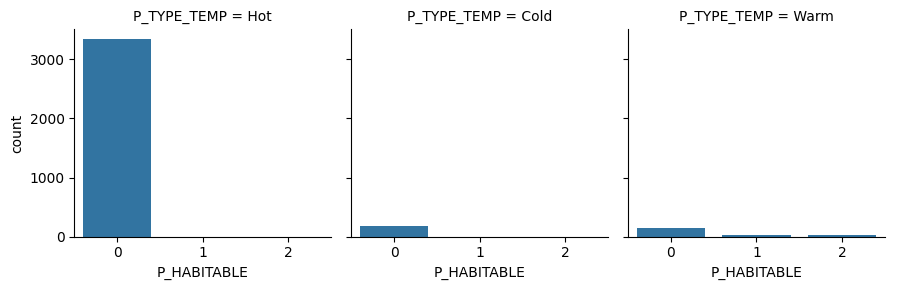

In [19]:
sns.axes_style(style='ticks')
g = sns.catplot(x = "P_HABITABLE", col = "P_TYPE_TEMP", col_wrap=3, data = df, kind = 'count', height= 3,aspect=1.0)
plt.savefig('ptype-by-target-distro.png')

The results indicate that Superterran planets are more frequently associated with positive habitability, whereas Terran planets show a higher number of potential habitable planets. In terms of stellar spectral type, M-type stars have a high occurrence of both conservatively and optimistically habitable planets. Additionally, warm planets show the highest numbers of both types of habitability, suggesting a strong association between warm thermal conditions and planetary habitability.


-------------------------------------------------------------------------------

Now we can plot how many habitable exoplanets were discovered over years

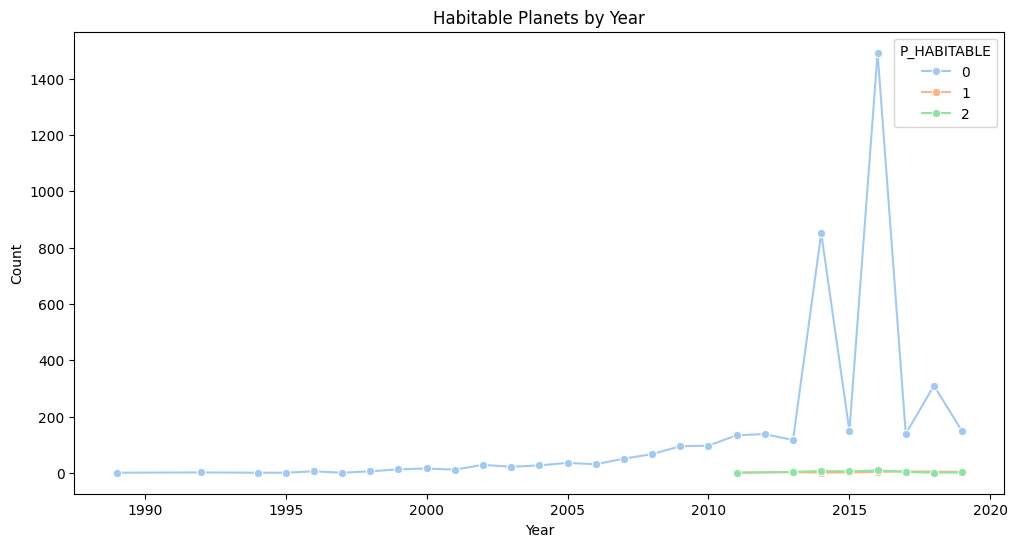

In [20]:
count_data = (
    df
    .groupby(["P_YEAR", "P_HABITABLE"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=count_data,
    x="P_YEAR",
    y="count",
    hue="P_HABITABLE",
    marker="o",
    palette="pastel"
)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Habitable Planets by Year")
plt.savefig("Habitable-Planets-by-Year.png")
plt.show()


From the above lineplot, we can infer that in around 2014-2015 we see maximum number of discovery of positive habitable exoplanet. In 2013, 2017, 2019, we see maximum discovery of potentially habitual exoplanets.

-------------------------------------------------------------------------------

Now, we can plot how planet thermal type is influencing the earth similarity index, and how PSI affect the possibility of and exoplanet being habitual.

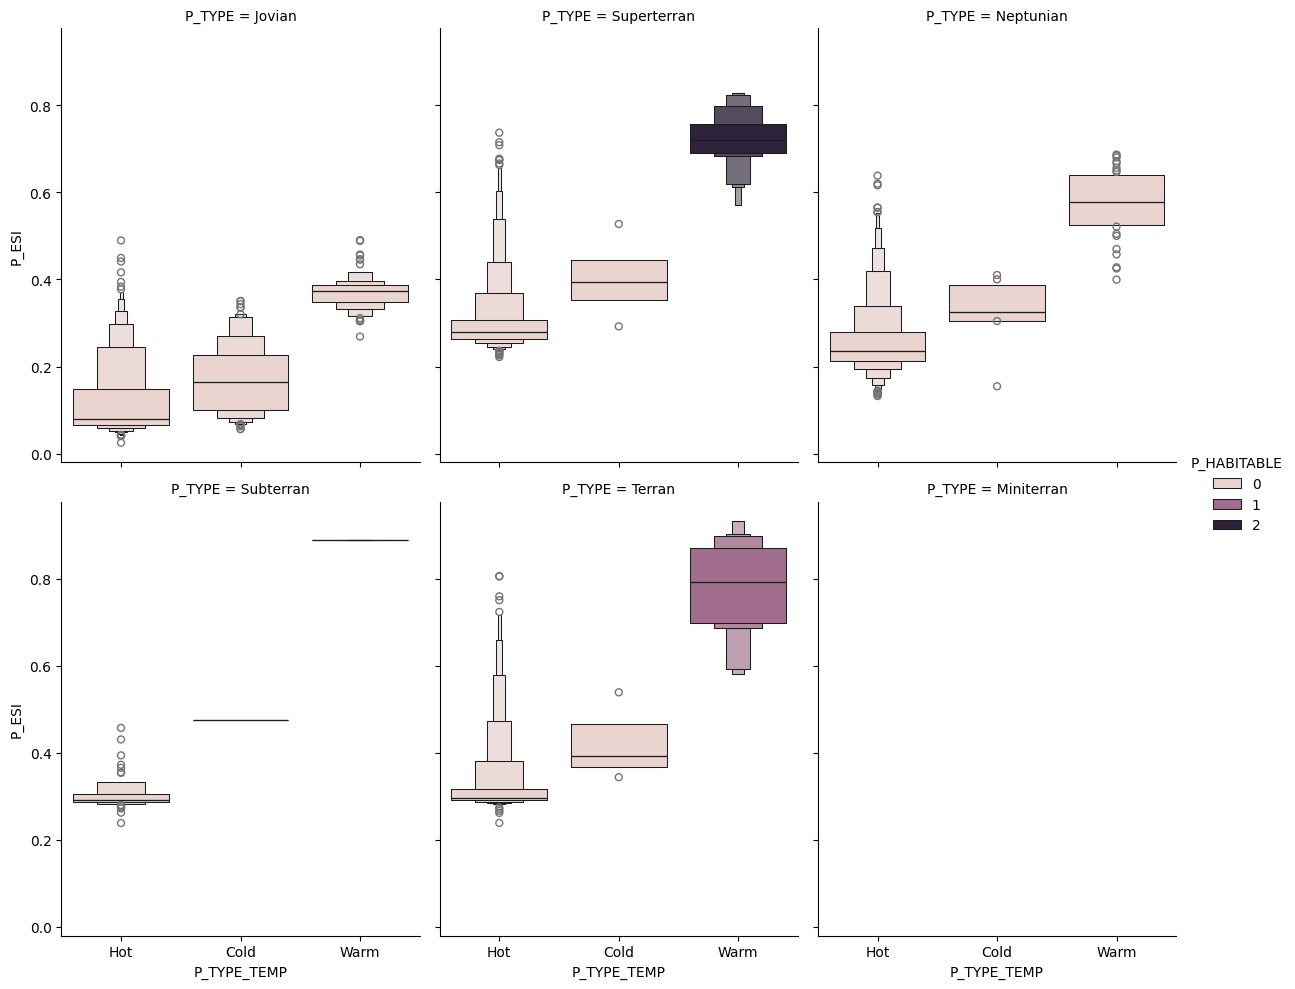

In [ ]:
df = df.reset_index(drop=True)
sns.catplot(x='P_TYPE_TEMP', y='P_ESI', hue= 'P_HABITABLE', col='P_TYPE', col_wrap=3, aspect=0.8, kind='boxen', data=df)
plt.savefig("P_type-by-temp.png")

We infer that a higher P_ESI is associated with a greater potential for habitability, as planets with higher ESI values have physical characteristics that are more similar to those of Earth. 

For super-Earth planets, the warm thermal type is associated with a higher number of optimistically habitable planets. In contrast, for terrestrial planets, the warm thermal type is associated with a higher number of conservatively habitable planets. These observations suggest that both planetary type and thermal characteristics may influence the potential habitability of exoplanets.


**Star constellation having habitable planets**

Let's plot names of the star constellations where most of the habitable exoplanets belong.

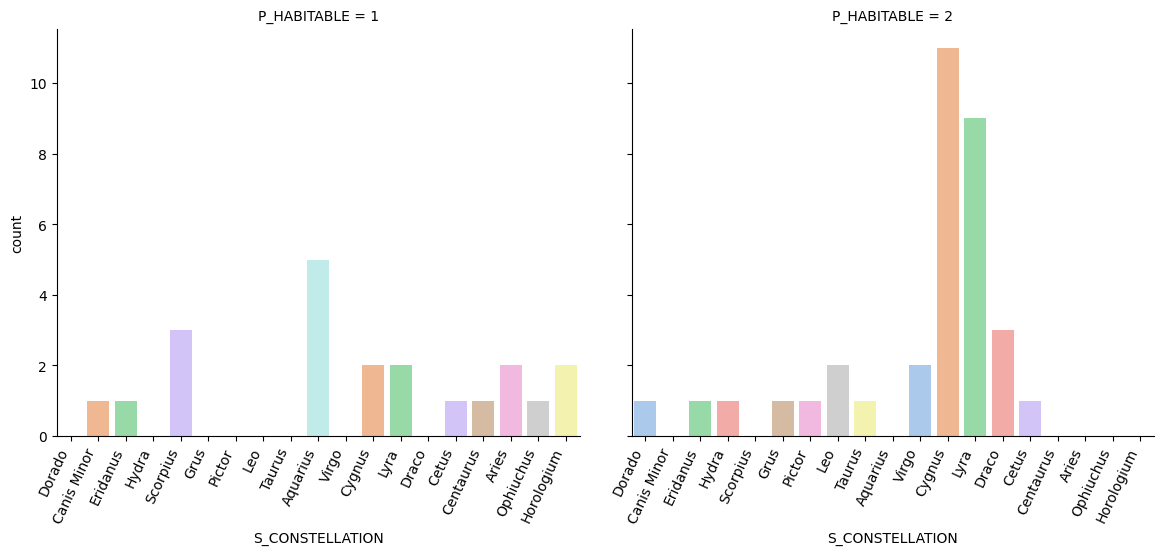

In [21]:
label_size = 10
plt.rcParams['xtick.labelsize'] = label_size
chart = sns.catplot(data=df[df['P_HABITABLE'].isin([1,2])],
                    x= 'S_CONSTELLATION',
                    kind = 'count',
                    palette = 'pastel',
                    col='P_HABITABLE',
                    aspect=1.2,)

chart.set_xticklabels(rotation=65, horizontalalignment='right')
plt.savefig("p-type-by-constellations.png")

We can note that constellation Aquarius has maximum number of potentially habitable exoplanets. Cygnus and Lyra has maximum number of Positive Habitual exoplanets.

**TIme Frame when planets with high ESI**

Now we will see how many exoplanets discoverd have high ESI

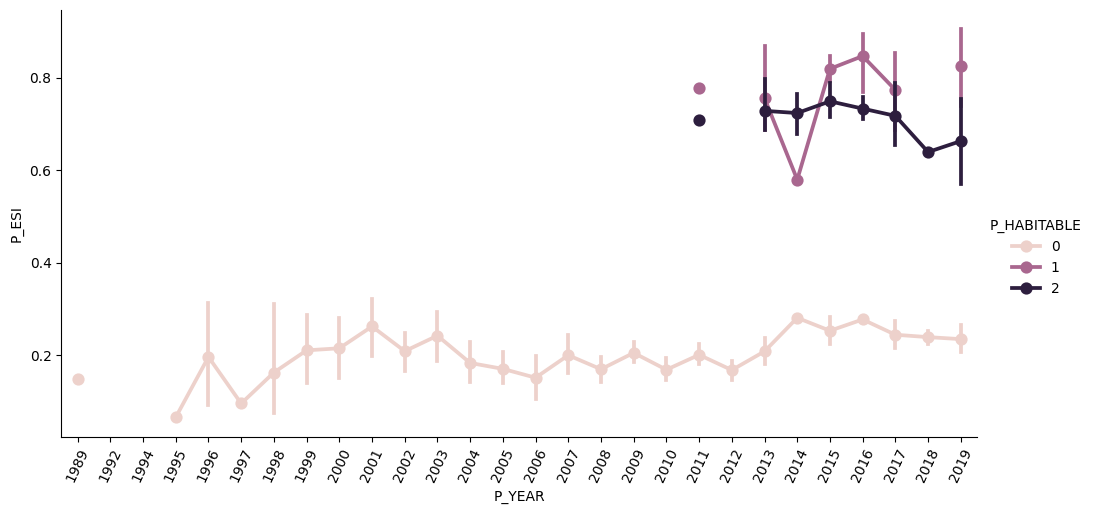

In [22]:
p_plot = sns.catplot(x='P_YEAR', y= 'P_ESI', hue='P_HABITABLE', kind= 'point', data=df, aspect=2.0)
p_plot.set_xticklabels(rotation=65)

Till 2017, only inhabitable planets had ESI <= 0.3 were discovered. From 2011-2019, habitable planets with ESI in the range of 0.6-0.9 have been discovered. 

**Influence of Planet mass/ Planet radius/ Planet eccentricity on habitability.**

In [23]:
import plotly.express as px
fig = px.scatter(df, x= df.P_MASS, y = df.P_ESI, color=df.P_HABITABLE, hover_name=df.P_NAME, log_x=True, size_max=30)
fig.show()

Planet mass in range 0.4 to 3.93 units corresponds to potentialy habitual exoplanets. Planet mass in range 5.4 to 8.92 units corresponds to positively habitual exoplanets. It is also important to note that, potentially habitual exoplanets have more ESI range then positively habitual exoplanets.  

In [24]:
import plotly.express as px
fig = px.scatter(df, x= df.P_RADIUS, y = df.P_ESI, color=df.P_HABITABLE, hover_name=df.P_NAME, log_x=True, size_max=30)

fig.show()

Planet radius in range 0.77 to 1.41 units correspond to conservatively habitable exoplanets. Planet radius in range 1.52 to 2.46 units correspond to optimistically habitable exoplanets. It is interesting to note that in most of the cases, conservatively habitable exoplanets have a bit higher ESI compared to the ESI of optimistically habitable exoplanets.

In [25]:
import plotly.express as px
fig = px.scatter(df, x= df.P_ECCENTRICITY, y = df.P_ESI, color=df.P_HABITABLE, hover_name=df.P_NAME, log_x=True, size_max=30)
fig.show()

Planet's eccentricity in the range 0.02 to 0.35 units indicate a possibility of habitability.

**Influence of Planetary Flux on habitability**

In [26]:
ESI_range = df.query("P_ESI> 0.65") 
fig = px.bar(ESI_range, x= 'P_NAME', y="P_FLUX", color = 'P_HABITABLE')
fig.show()

We can clearly see that, very high flux is associated with potentially habitual planets and moderately high flux is associated with positive habitual planets. Inhabitable planets have very low flux.

**Influence of age of planet(P_PERIOD) on habitability**

In [27]:
fig = px.line(ESI_range, x="P_NAME", y= "P_PERIOD", color = 'P_HABITABLE',line_group="P_TYPE")
fig.show()

We can see that potentially habitual cluster of exoplanets have period ranging between 9 days to 267 days. 

Positively habitual cluster of exoplanets have a period ranging 18 days to  448 days.

### **PREPRCESSING**

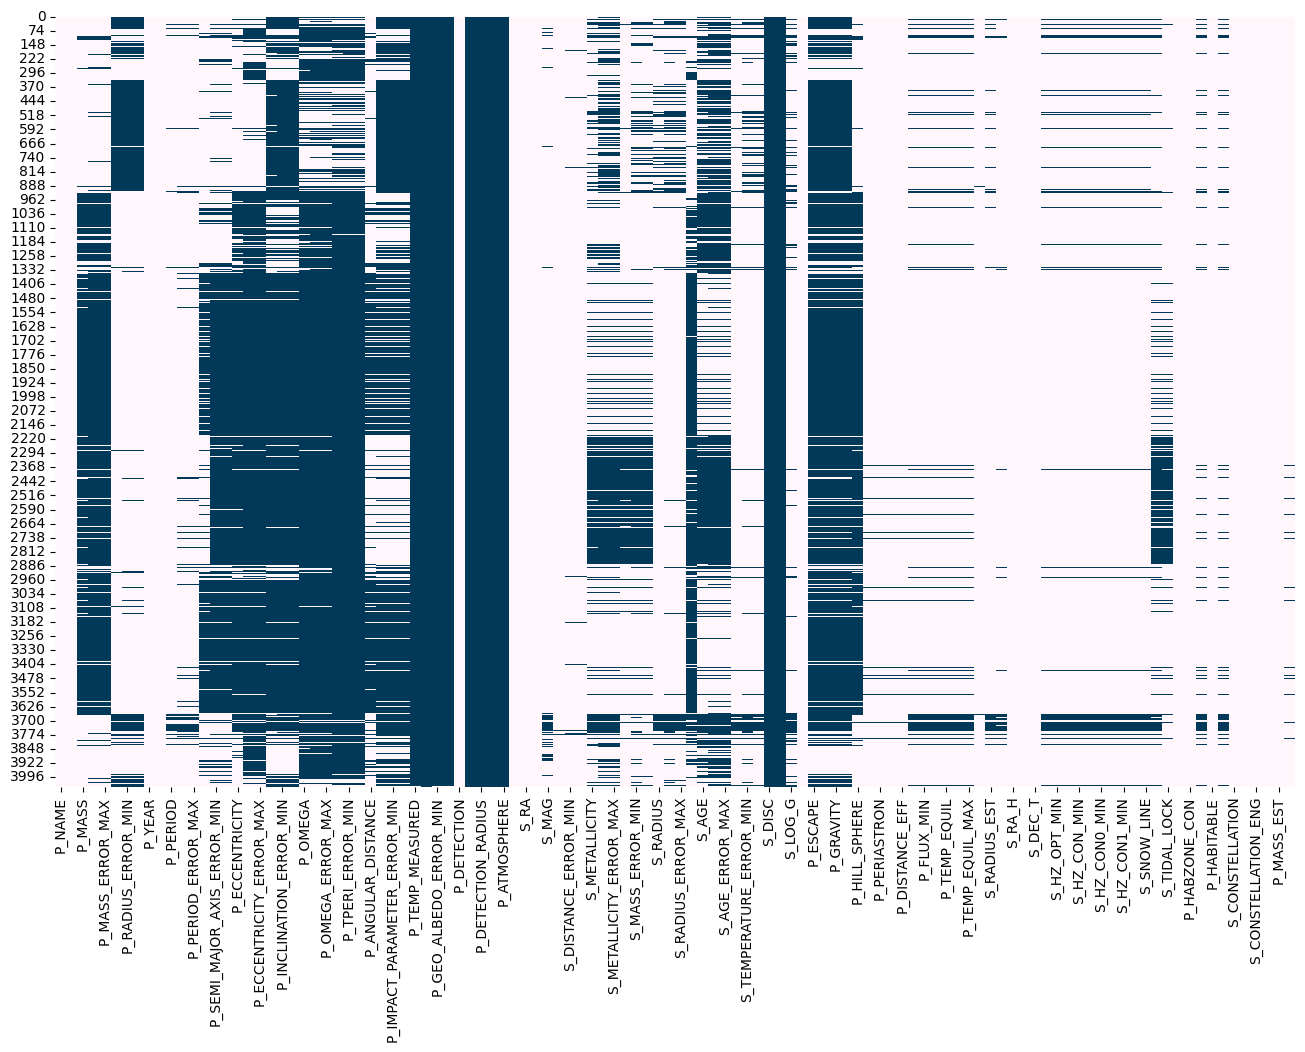

In [54]:
#Plots a heatmap of the missing values in the dataset
plt.figure(figsize=(16, 10))

sns.heatmap(df.isnull(), cbar=False, cmap='PuBu') 
plt.savefig('Null-values-distribution.png')
plt.show()

In [55]:
null_values = df.isnull().sum().sort_values(ascending = False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)

missing = pd.concat([null_values,percent], axis = 1, keys=['Total', "Percent"])
missing.head(40)

,Total,Percent
P_ATMOSPHERE,4048,1.000000
P_ALT_NAMES,4048,1.000000
P_DETECTION_RADIUS,4048,1.000000
P_GEO_ALBEDO,4048,1.000000
P_DETECTION_MASS,4048,1.000000
S_MAGNETIC_FIELD,4048,1.000000
S_DISC,4048,1.000000
P_TEMP_MEASURED,4043,0.998765
P_GEO_ALBEDO_ERROR_MIN,4043,0.998765
P_GEO_ALBEDO_ERROR_MAX,4043,0.998765


We can safely remove those features which have missing values > 50% of data to reduce bias.

In [56]:
#Dropping all the columns with null  values
df = df.drop( [ "P_ATMOSPHERE", "P_ALT_NAMES", "P_DETECTION_RADIUS", "P_GEO_ALBEDO", "P_DETECTION_MASS","S_MAGNETIC_FIELD", "S_DISC", "P_TEMP_MEASURED", "P_GEO_ALBEDO_ERROR_MIN", "P_GEO_ALBEDO_ERROR_MAX","P_TPERI_ERROR_MAX", "P_TPERI_ERROR_MIN", "P_TPERI", "P_OMEGA_ERROR_MIN", "P_OMEGA_ERROR_MAX","P_ESCAPE", "P_POTENTIAL", "P_DENSITY", "P_GRAVITY", "P_OMEGA","P_INCLINATION_ERROR_MAX", "P_INCLINATION_ERROR_MIN", "P_INCLINATION","P_ECCENTRICITY_ERROR_MIN", "P_ECCENTRICITY_ERROR_MAX", "S_TYPE", "P_ECCENTRICITY","P_IMPACT_PARAMETER_ERROR_MIN", "P_IMPACT_PARAMETER_ERROR_MAX", "P_IMPACT_PARAMETER","P_MASS_ERROR_MAX", "P_MASS_ERROR_MIN", "P_HILL_SPHERE", 'P_ESI',"P_SEMI_MAJOR_AXIS_ERROR_MIN", "P_SEMI_MAJOR_AXIS_ERROR_MAX", "P_MASS","S_AGE_ERROR_MIN", "S_AGE_ERROR_MAX"], axis=1)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11979 entries, 0 to 137
Data columns (total 73 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   P_NAME                   11979 non-null  object 
 1   P_STATUS                 11979 non-null  float64
 2   P_RADIUS                 8195 non-null   float64
 3   P_RADIUS_ERROR_MIN       8161 non-null   float64
 4   P_RADIUS_ERROR_MAX       8161 non-null   float64
 5   P_YEAR                   11979 non-null  int64  
 6   P_UPDATED                11979 non-null  object 
 7   P_PERIOD                 11869 non-null  float64
 8   P_PERIOD_ERROR_MIN       11738 non-null  float64
 9   P_PERIOD_ERROR_MAX       11738 non-null  float64
 10  P_SEMI_MAJOR_AXIS        8969 non-null   float64
 11  P_ANGULAR_DISTANCE       8963 non-null   float64
 12  P_DETECTION              11979 non-null  object 
 13  S_NAME                   11979 non-null  object 
 14  S_RA                     1197

In [81]:
X= df.drop(columns=["P_HABITABLE"])
y = df["P_HABITABLE"]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)

In [82]:
X_categorical_train = X_train.select_dtypes(include=['object'])
X_numerical_train = X_train.select_dtypes(include="number")

X_categorical_test = X_test.select_dtypes(include=['object'])
X_numerical_test = X_test.select_dtypes(include="number")

Our data is divided into categorical and numeric datatypes

In [83]:
X_categorical_train.select_dtypes(include=['object']).columns

Index(['P_NAME', 'P_UPDATED', 'P_DETECTION', 'S_NAME', 'S_ALT_NAMES', 'P_TYPE',
       'S_TYPE_TEMP', 'S_RA_T', 'S_DEC_T', 'P_TYPE_TEMP', 'S_CONSTELLATION',
       'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG'],
      dtype='object')

In [84]:
total = X_categorical_train.isnull().sum().sort_values(ascending = False)
percent = (X_categorical_train.isnull().sum()/X_categorical_train.isnull().count()).sort_values(ascending=False)

missing = pd.concat([total,percent], axis = 1, keys=['Total', "Percent"])
missing.head(40)

,Total,Percent
P_TYPE_TEMP,260,0.080296
S_TYPE_TEMP,110,0.033972
P_TYPE,13,0.004015
P_UPDATED,0,0.000000
P_NAME,0,0.000000
S_ALT_NAMES,0,0.000000
S_NAME,0,0.000000
P_DETECTION,0,0.000000
S_RA_T,0,0.000000
S_DEC_T,0,0.000000


We can fill the missing values by imputation using mode

In [87]:
from sklearn.impute import SimpleImputer

cat_imputer = SimpleImputer(strategy="most_frequent")

X_categorical_train = pd.DataFrame(
    cat_imputer.fit_transform(X_categorical_train),
    columns=X_categorical_train.columns,
    index=X_categorical_train.index
)

X_categorical_test = pd.DataFrame(
    cat_imputer.transform(X_categorical_test),
    columns=X_categorical_test.columns,
    index=X_categorical_test.index
)


Now we can convert categorical column to numeric by label encoding

In [89]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_categorical_train_encoded = pd.DataFrame(
    encoder.fit_transform(X_categorical_train),
    columns=encoder.get_feature_names_out(X_categorical_train.columns),
    index=X_categorical_train.index
)

X_categorical_test_encoded = pd.DataFrame(
    encoder.transform(X_categorical_test),
    columns=encoder.get_feature_names_out(X_categorical_test.columns),
    index=X_categorical_test.index
)


In [90]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_numerical_train = pd.DataFrame(
    imputer.fit_transform(X_numerical_train),
    columns=X_numerical_train.columns,
    index=X_numerical_train.index
)

X_numerical_test = pd.DataFrame(
    imputer.transform(X_numerical_test),
    columns=X_numerical_test.columns,
    index=X_numerical_test.index
)


<Axes: >

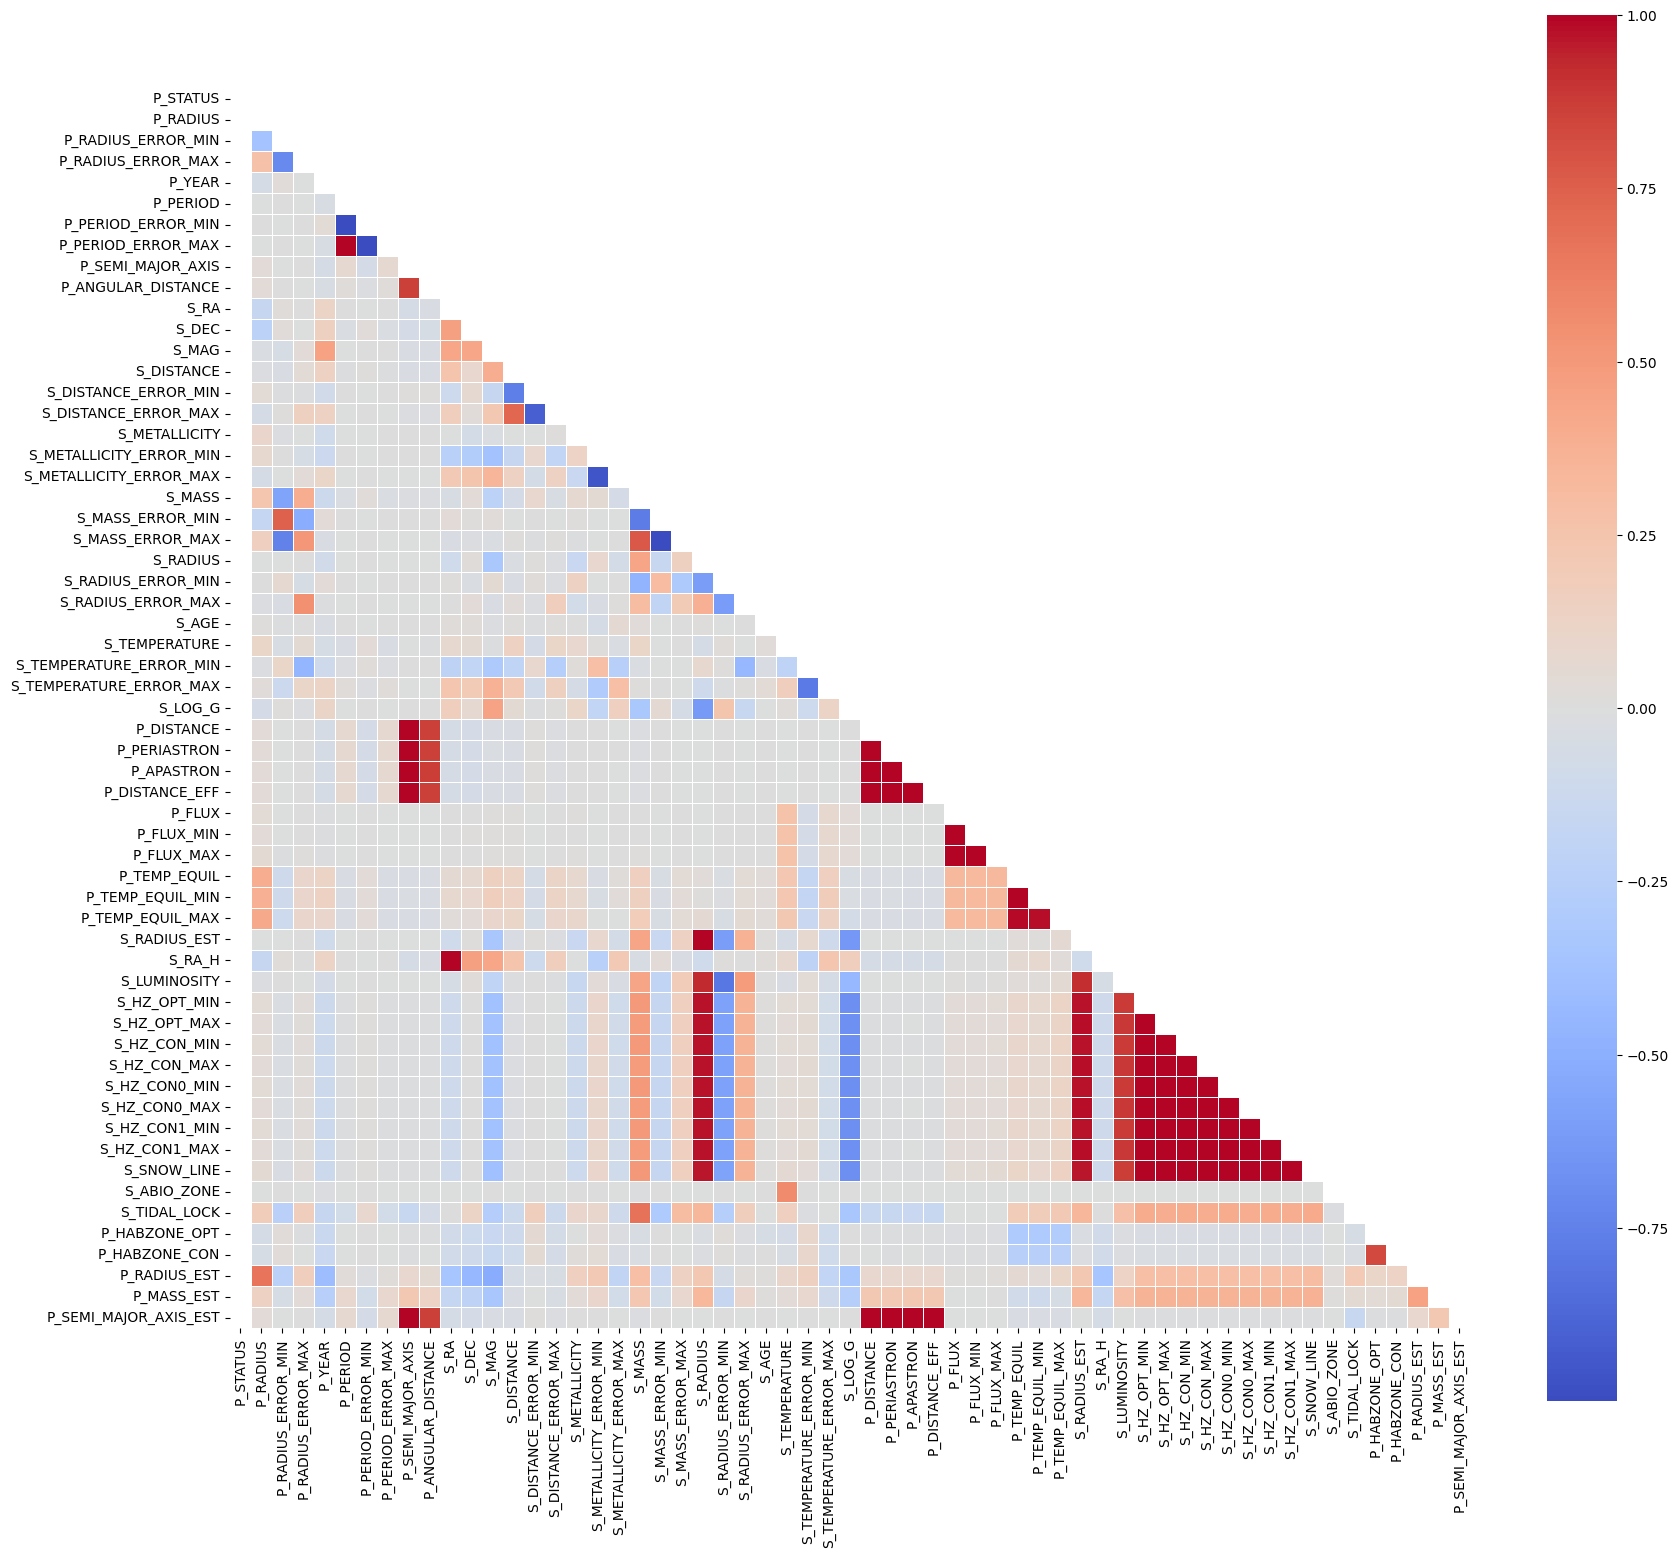

In [91]:
corr = X_numerical_train.corr()
mask = np.triu(np.ones_like(corr, dtype=np.bool))
f,ax = plt.subplots(figsize=(20,20))

sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True,annot=False, linewidths=.5, cbar_kws={"shrink": 0.9})

nOw WE HANDLED MISSING VALUES IN CATEGORICAL DATA and encoded them, NO WE WILL WORK UPON NUMERICAL DATA 

We are going to use Scikit-learn's imputer because it provides a systematic way to replace missing numerical data, and IterativeImputer is particularly useful when we want to use relationships between multiple features to make those replacements.


we have corrected all of our missing values!

Now we can work with fixing multicollinearity 

Dark red square are the one which shows, features which are highly co-related. We can drop one of each.

In [94]:
#Dropping one of each which are highly corelated to each other
X_numerical_train_dropped = X_numerical_train.drop(['P_RADIUS', 'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX', 'P_DISTANCE', 'P_PERIASTRON', 'P_APASTRON', 'P_DISTANCE_EFF', 'P_FLUX_MIN', 'P_FLUX_MAX', 'P_TEMP_EQUIL', 'P_TEMP_EQUIL_MIN', 'P_TEMP_EQUIL_MAX', 'S_RADIUS_EST', 'S_RA_H', 'S_LUMINOSITY', 'S_HZ_OPT_MIN', 'S_HZ_OPT_MAX', 'S_HZ_CON_MIN', 'S_HZ_CON_MAX', 'S_HZ_CON0_MIN', 'S_HZ_CON0_MAX', 'S_HZ_CON1_MIN', 'S_HZ_CON1_MAX', 'S_SNOW_LINE', 'P_PERIOD_ERROR_MIN', 'P_PERIOD_ERROR_MAX', 'S_MAG', 'S_DISTANCE_ERROR_MIN', 'S_DISTANCE_ERROR_MAX', 'S_METALLICITY', 'S_METALLICITY_ERROR_MIN', 'S_METALLICITY_ERROR_MAX', 'S_AGE', 'S_TEMPERATURE_ERROR_MIN', 'S_TEMPERATURE_ERROR_MAX', 'S_ABIO_ZONE', 'P_SEMI_MAJOR_AXIS_EST'], axis=1)

#Dropping one of each which are highly corelated to each other
X_numerical_test_dropped = X_numerical_test.drop(['P_RADIUS', 'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX', 'P_DISTANCE', 'P_PERIASTRON', 'P_APASTRON', 'P_DISTANCE_EFF', 'P_FLUX_MIN', 'P_FLUX_MAX', 'P_TEMP_EQUIL', 'P_TEMP_EQUIL_MIN', 'P_TEMP_EQUIL_MAX', 'S_RADIUS_EST', 'S_RA_H', 'S_LUMINOSITY', 'S_HZ_OPT_MIN', 'S_HZ_OPT_MAX', 'S_HZ_CON_MIN', 'S_HZ_CON_MAX', 'S_HZ_CON0_MIN', 'S_HZ_CON0_MAX', 'S_HZ_CON1_MIN', 'S_HZ_CON1_MAX', 'S_SNOW_LINE', 'P_PERIOD_ERROR_MIN', 'P_PERIOD_ERROR_MAX', 'S_MAG', 'S_DISTANCE_ERROR_MIN', 'S_DISTANCE_ERROR_MAX', 'S_METALLICITY', 'S_METALLICITY_ERROR_MIN', 'S_METALLICITY_ERROR_MAX', 'S_AGE', 'S_TEMPERATURE_ERROR_MIN', 'S_TEMPERATURE_ERROR_MAX', 'S_ABIO_ZONE', 'P_SEMI_MAJOR_AXIS_EST'], axis=1)

In [96]:
X_train_final = pd.concat(
    [X_numerical_train_dropped, X_categorical_train_encoded],
    axis=1
)

X_test_final = pd.concat(
    [X_numerical_test_dropped, X_categorical_test_encoded],
    axis=1
)

print(X_train_final.shape)
print(X_test_final.shape)


(3238, 11811)
(810, 11811)


In [97]:
print(X_numerical_train_dropped.shape)
print(X_categorical_train_encoded.shape)

(3238, 22)
(3238, 11789)


In [107]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_train_reduced = selector.fit_transform(X_train_final)
X_test_reduced = selector.transform(X_test_final)

print(X_train_final.shape)
print(X_train_reduced.shape)
print(X_test_final.shape)
print(X_test_reduced.shape)

(3238, 11811)
(3238, 87)
(810, 11811)
(810, 87)


In [108]:
selected_features = X_train_final.columns[
    selector.get_support()
]

X_train_selected = pd.DataFrame(
    X_train_selected,
    columns=selected_features,
    index=X_train_final.index
)

X_test_selected = pd.DataFrame(
    X_test_selected,
    columns=selected_features,
    index=X_test_final.index
)

In [ ]:
#Random Forest Classifier feature importance
selector = SelectFromModel(RandomForestClassifier(n_estimators=1000, random_state=0))
selector.fit(X_train_selected,y_train)

support = selector.get_support()
features = X_train_selected.loc[:,support].columns.tolist()
print(features)


['P_PERIOD', 'P_SEMI_MAJOR_AXIS', 'P_ANGULAR_DISTANCE', 'S_DISTANCE', 'S_MASS', 'S_RADIUS', 'S_RADIUS_ERROR_MIN', 'S_RADIUS_ERROR_MAX', 'S_TEMPERATURE', 'S_LOG_G', 'P_FLUX', 'P_HABZONE_OPT', 'P_HABZONE_CON', 'P_RADIUS_EST', 'P_MASS_EST', 'P_TYPE_Jovian', 'P_TYPE_Superterran', 'P_TYPE_Terran', 'P_TYPE_TEMP_Hot', 'P_TYPE_TEMP_Warm']


In [113]:
X_train_top20 = X_train_selected.loc[:, support]
X_test_top20 = X_test_selected.loc[:, support]

In [114]:
print(X_train_top20.shape)
print(X_test_top20.shape)

(3238, 20)
(810, 20)


In [ ]:
X_train_top20 = X_train_top20.drop(['P_HABZONE_OPT', 'P_HABZONE_CON'], axis =1)
X_test_top20 = X_test_top20.drop(['P_HABZONE_OPT', 'P_HABZONE_CON'],axis = 1) 


(3238, 18)
(810, 18)


In [137]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy={1: 1595, 2: 1595},random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_top20,
    y_train
)

In [138]:
print(y_train.value_counts())
print(y_train_resampled.value_counts())

P_HABITABLE
0    3190
2      31
1      17
Name: count, dtype: int64
P_HABITABLE
0    3190
1    1595
2    1595
Name: count, dtype: int64


Now we can work upon detecting outliers and removing them

# **FEATURE SELECTION**

Now that we have processed and analyzed all the data, we can finally select those features which are really important

For selecting the important features, we will separate them using 2 techniques

1) Random Forest feature Importance
2) Permutation Importance

From both the sets of feature importance, we will chose the one which was common in both.

## **Splitting into Train/Test**

In [139]:
#Scaling the features
scaler = StandardScaler()

X_train_new = scaler.fit_transform(X_train_resampled)
X_test_new = scaler.transform(X_test_top20)

# **TRAINING**

Since our target column is of multi-class, we will use one-vs-rest strategy. This strategy breaks down multi class problem to binary class and then compares them.

In [140]:
def run_models(model, X_train_new, y_train_resampled, X_test_new, y_test, verbose=True):

    if verbose == False:
        model_ovr = Ovr(model)
        model_ovr.fit(X_train_new, y_train_resampled, verbose = 0)
    else:
        model_ovr = Ovr(model)
        model_ovr.fit(X_train_new,y_train_resampled)

    y_pred = model_ovr.predict(X_test_new)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    recall  = recall_score(y_test, y_pred, average='macro')

    print("Accuracy = {}".format(accuracy))
    print("Precision = {}".format(precision))
    print("F1 score = {}".format(f1))
    print("Recall Score = {}".format(recall))
    print(classification_report(y_test, y_pred, digits = 5))

    return accuracy, precision, f1, recall

In [141]:
# Check shape alignment
print(f"X_train_new: {X_train_new.shape}")
print(f"y_train_resampled: {y_train_resampled.shape}")

X_train_new: (6380, 18)
y_train_resampled: (6380,)


Training all the different models

In [153]:
model_lr = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')
param_grid_lr = {
    'C': [0.00001, 0.0001, 0.001, 0.01, 0.1], 
    'penalty': ['l2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_lr = GridSearchCV(model_lr, param_grid_lr, cv=cv, scoring='f1_macro', n_jobs=-1)
grid_lr.fit(X_train_new, y_train_resampled)  # ✓ now aligned
best_lr = grid_lr.best_estimator_

# ✓ Use best_lr, not model_lr
accuracy_lr, precision_lr, f1_lr, recall_lr = run_models(
    best_lr, X_train_new, y_train_resampled, X_test_new, y_test
)

Accuracy = 0.9962962962962963
Precision = 0.8055555555555555
F1 score = 0.8850904553961323
Recall Score = 0.9987546699875467
              precision    recall  f1-score   support

           0    1.00000   0.99626   0.99813       803
           1    0.66667   1.00000   0.80000         4
           2    0.75000   1.00000   0.85714         3

    accuracy                        0.99630       810
   macro avg    0.80556   0.99875   0.88509       810
weighted avg    0.99743   0.99630   0.99663       810



In [154]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix

y_pred = best_lr.predict(X_test_new)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Macro:  {f1:.4f}")
print(f"Recall:    {recall:.4f}")

Accuracy:  0.9988
Precision: 0.9333
F1 Macro:  0.9628
Recall:    0.9996


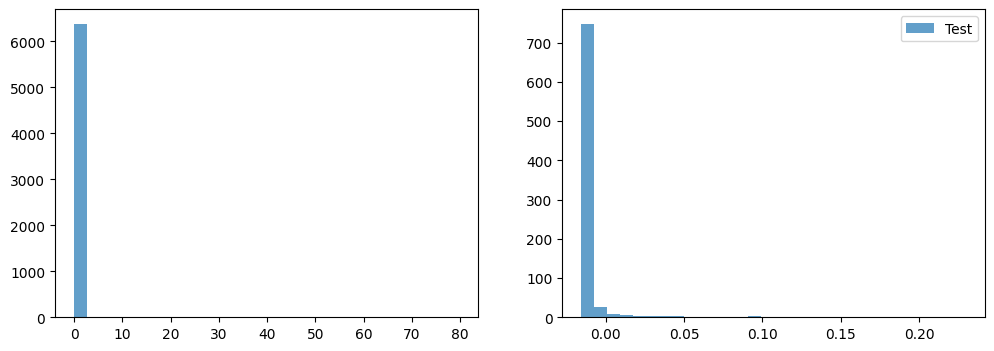

Max similarity (test vs train): 1.0000


In [155]:
# 1. Compare feature distributions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train_new[:, 0], bins=30, alpha=0.7, label='Train')
axes[1].hist(X_test_new[:, 0], bins=30, alpha=0.7, label='Test')
plt.legend()
plt.show()

# 2. Check if any test samples are in training data
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(X_test_new[:10], X_train_new)
print(f"Max similarity (test vs train): {similarity.max():.4f}")

In [156]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_lr, X_train_new, y_train_resampled, cv=5, scoring='f1_macro')
print(f"CV F1 scores: {cv_scores}")
print(f"CV mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# If CV mean is much lower than test F1, test set is easier

CV F1 scores: [0.99843505 1.         1.         0.99921691 0.99765114]
CV mean: 0.9991 ± 0.0009


In [151]:
# Double-check what you're running
print(f"Best C: {best_lr.C}")
print(f"Best params: {grid_lr.best_params_}")

# Verify confusion matrix matches metrics
from sklearn.metrics import confusion_matrix
y_test_pred = best_lr.predict(X_test_new)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Best C: 0.1
Best params: {'C': 0.1, 'penalty': 'l2'}

Confusion Matrix:
[[802   1   0]
 [  0   4   0]
 [  0   0   3]]


In [148]:
# Print train vs test metrics separately
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

# Train metrics
y_train_pred = best_lr.predict(X_train_new)
print("TRAIN Metrics:")
print(f"  Accuracy:  {accuracy_score(y_train_resampled, y_train_pred):.4f}")
print(f"  F1 Macro:  {f1_score(y_train_resampled, y_train_pred, average='macro'):.4f}")
print(f"  Precision: {precision_score(y_train_resampled, y_train_pred, average='macro'):.4f}")
print(f"  Recall:    {recall_score(y_train_resampled, y_train_pred, average='macro'):.4f}")

# Test metrics
y_test_pred = best_lr.predict(X_test_new)
print("\nTEST Metrics:")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  F1 Macro:  {f1_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred, average='macro'):.4f}")

TRAIN Metrics:
  Accuracy:  0.9994
  F1 Macro:  0.9994
  Precision: 0.9992
  Recall:    0.9996

TEST Metrics:
  Accuracy:  0.9988
  F1 Macro:  0.9628
  Precision: 0.9333
  Recall:    0.9996


In [128]:
#Decision Tree

dt = DecisionTreeClassifier(random_state=42)


param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],           
    'min_samples_split': [20, 30, 50],    
    'min_samples_leaf': [10, 15, 20],     
    'max_features': ['sqrt', 'log2'] 
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)


best_dt = grid_search.best_estimator_

accuracy_dt, precision_dt, f1_dt, recall_dt = run_models(best_dt,X_train,y_train,X_test,y_test)


Fitting 5 folds for each of 144 candidates, totalling 720 fits


ValueError: 
All the 720 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
576 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\tree\_classes.py", line 1027, in fit
    super()._fit(
    ~~~~~~~~~~~~^
        X,
        ^^
    ...<2 lines>...
        check_input=che

In [68]:
#Gradient Boosting

gb = GradientBoostingClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100],           
    'learning_rate': [0.001, 0.01],      
    'max_depth': [2, 3, 4],              
    'min_samples_split': [30, 50],       
    'min_samples_leaf': [15, 20],        
    'subsample': [0.6, 0.7],             
    'max_features': ['sqrt'] 
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_gb = GridSearchCV(gb, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_

accuracy_gb, precision_gb, f1_gb, recall_gb = run_models(
    best_gb, X_train, y_train, X_test, y_test
)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Accuracy = 0.9832689832689833
Precision = 0.9879600963192295
F1 score = 0.9586947951891024
Recall Score = 0.9362745098039215
              precision    recall  f1-score   support

           0    1.00000   0.80882   0.89431        68
           1    0.98246   1.00000   0.99115       392
           2    0.98142   1.00000   0.99062       317

    accuracy                        0.98327       777
   macro avg    0.98796   0.93627   0.95869       777
weighted avg    0.98357   0.98327   0.98246       777



In [ ]:
# Random Forest
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 8],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    rf, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1
)


grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_


accuracy_rf, precision_rf, f1_rf, recall_rf = run_models(
    best_rf, X_train, y_train, X_test, y_test
)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Accuracy = 0.9987129987129987
Precision = 0.9991518235793045
F1 score = 0.9971062357474247
Recall Score = 0.9950980392156863
              precision    recall  f1-score   support

           0    1.00000   0.98529   0.99259        68
           1    0.99746   1.00000   0.99873       392
           2    1.00000   1.00000   1.00000       317

    accuracy                        0.99871       777
   macro avg    0.99915   0.99510   0.99711       777
weighted avg    0.99872   0.99871   0.99871       777



# **MODEL COMPARISON**

In [69]:
results = {
    "Model": [
        "Decision Tree",
        "Logistic Regression",
        "Gradient Boosting Classifier",
        "Random Forest"
    ],
    "Accuracy": [
        0.9974259974259975,
        0.9884169884169884,
        0.9832689832689833,
        0.9987129987129987
    ],
    "Precision": [
        0.9983079526226734,
        0.9912764039659834,
        0.9879600963192295,
        0.9991518235793045
    ],
    "Recall": [
        0.9901960784313726,
        0.9558823529411765,
        0.9362745098039215,
        0.9950980392156863
    ],
    "F1 Score": [
        0.9941766992011951,
        0.9719823047254099,
        0.9586947951891024,
        0.9971062357474247
    ]
}
comparison_df = pd.DataFrame(results)

metric_columns = ["Accuracy", "Precision", "Recall", "F1 Score"]
comparison_df[metric_columns] = comparison_df[metric_columns] * 100

comparison_df = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

comparison_df.round(2)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,99.87,99.92,99.51,99.71
1,Decision Tree,99.74,99.83,99.02,99.42
2,Logistic Regression,98.84,99.13,95.59,97.20
3,Gradient Boosting Classifier,98.33,98.80,93.63,95.87


In [70]:
best_model = comparison_df.iloc[0]

print("\n----- FINAL VERDICT -----")
print(f"Best Model: {best_model['Model']}")
print(f"Accuracy : {best_model['Accuracy']:.2f}%")
print(f"Precision: {best_model['Precision']:.2f}%")
print(f"Recall   : {best_model['Recall']:.2f}%")
print(f"F1 Score : {best_model['F1 Score']:.2f}%")


----- FINAL VERDICT -----
Best Model: Random Forest
Accuracy : 99.87%
Precision: 99.92%
Recall   : 99.51%
F1 Score : 99.71%


In [71]:
from sklearn.pipeline import Pipeline
import joblib

pipeline = Pipeline([
    ("scaler", scaler),
    ("model", rf_model)
])

joblib.dump(pipeline, "model.pkl")

['model.pkl']